<a href="https://colab.research.google.com/github/aditik-20/CustomerSeg_Churn/blob/main/CustomerSeg_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [3]:
df


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [4]:
df.shape

(7043, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


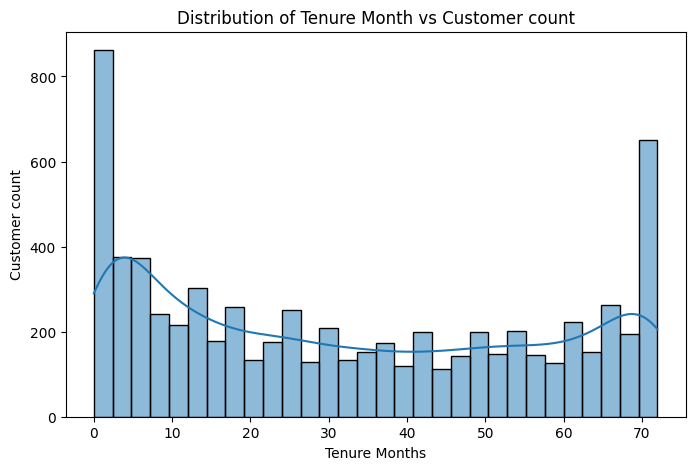

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'],bins = 30 , kde =True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Month vs Customer count')
plt.show()

In [8]:
df['Tenure Months'].max()

72

In [9]:
df['Tenure Months'].min()

0

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

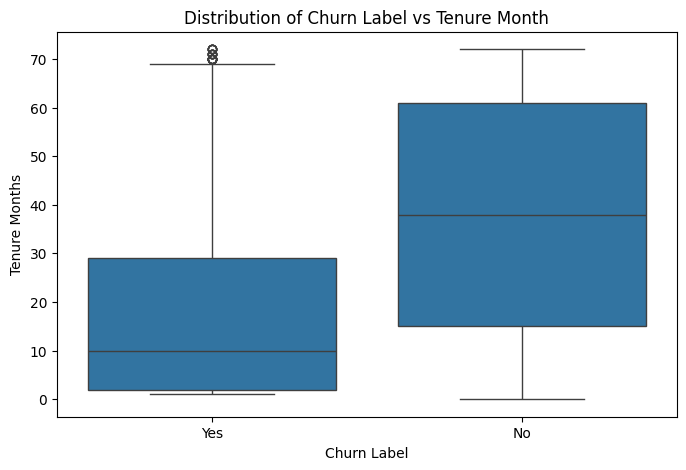

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y = 'Tenure Months',data = df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Distribution of Churn Label vs Tenure Month')
plt.show()

In [12]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

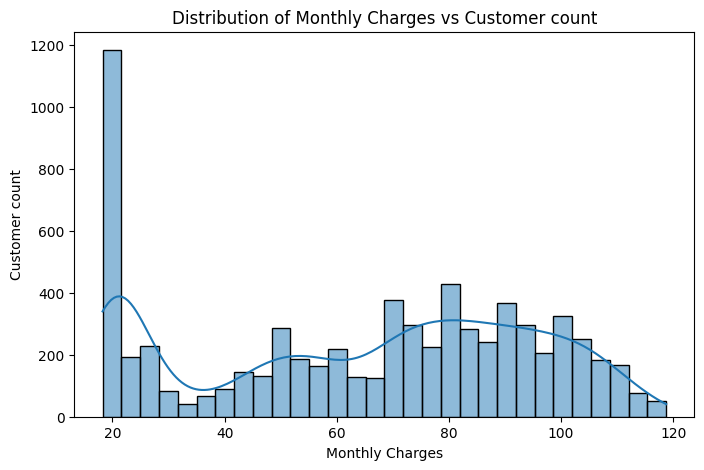

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'],bins = 30 , kde =True)
plt.xlabel('Monthly Charges')
plt.ylabel('Customer count')
plt.title('Distribution of Monthly Charges vs Customer count')
plt.show()

In [14]:
df['Monthly Charges'].max()

118.75

In [15]:
df['Monthly Charges'].min()

18.25

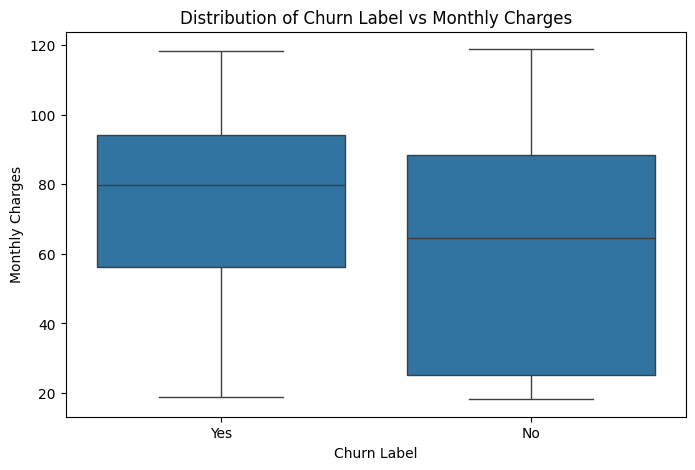

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y = 'Monthly Charges',data = df)
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('Distribution of Churn Label vs Monthly Charges')
plt.show()

In [17]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [18]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [19]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [20]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [21]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

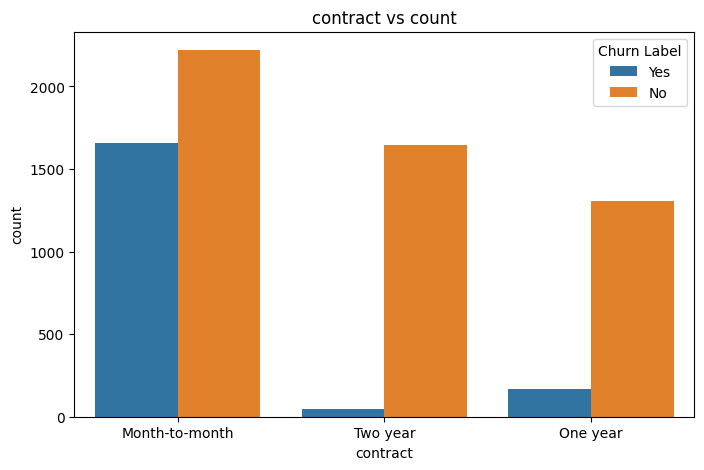

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract',

hue='Churn Label', data=df)

plt.xlabel('contract')

plt.ylabel('count')

plt.title('contract vs count')

plt.show()

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [24]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

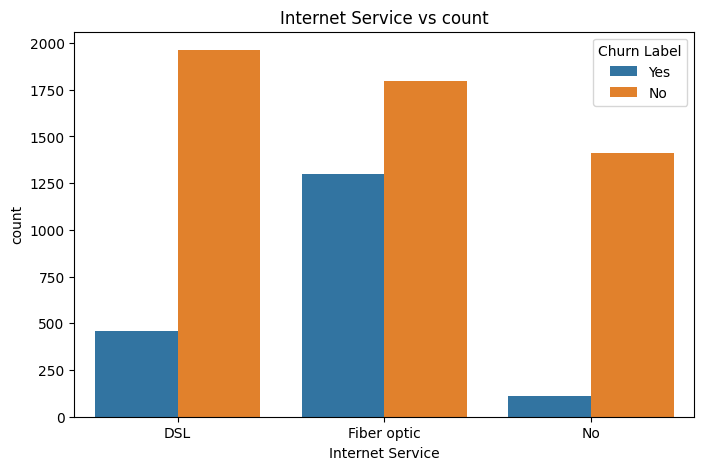

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(x='Internet Service',

hue='Churn Label', data=df)

plt.xlabel('Internet Service')

plt.ylabel('count')

plt.title('Internet Service vs count')

plt.show()

In [26]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

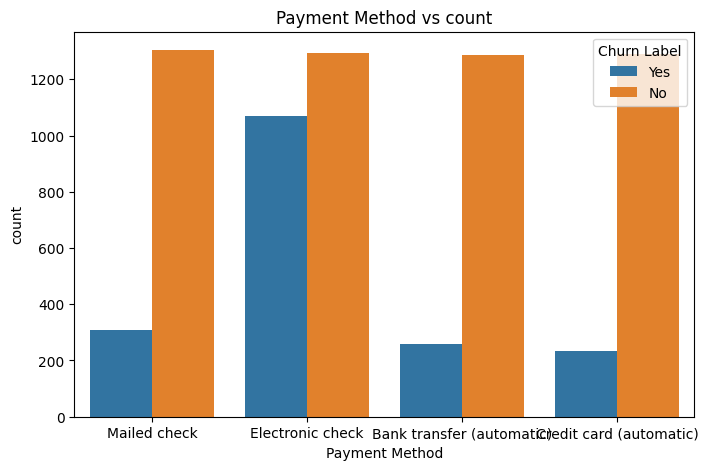

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(x='Payment Method',

hue='Churn Label', data=df)

plt.xlabel('Payment Method')

plt.ylabel('count')

plt.title('Payment Method vs count')

plt.show()

In [28]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

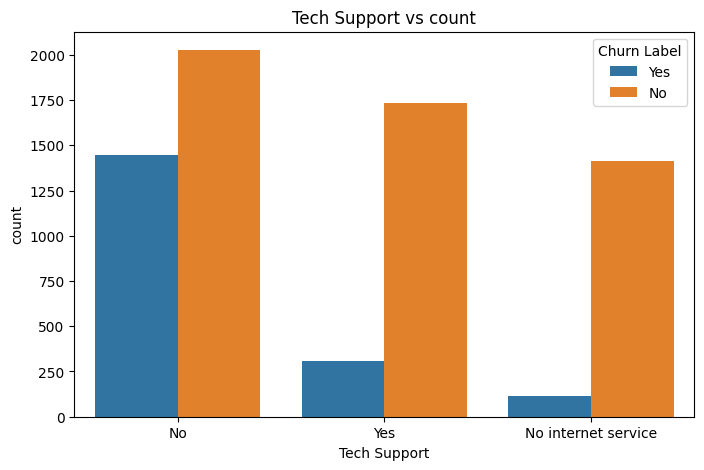

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(x='Tech Support',

hue='Churn Label', data=df)

plt.xlabel('Tech Support')

plt.ylabel('count')

plt.title('Tech Support vs count')

plt.show()

In [30]:
avg_tenure = df.groupby('Churn Label')['Tenure Months'].mean()

In [31]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [33]:
numerical_cols=['Tenure Months' , 'Monthly Charges' , 'Churn Value' , 'CLTV' ]
correlation_matrix=df[numerical_cols].corr()

In [34]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,CLTV
Tenure Months,1.000000,0.247900,-0.352229,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.098693
Churn Value,-0.352229,0.193356,1.000000,-0.127463
CLTV,0.396406,0.098693,-0.127463,1.000000


In [35]:
contract_churn = pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Data Cleaning**

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [37]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [38]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [39]:
df['Total Charges'].dtype

dtype('float64')

In [40]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [41]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [42]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [43]:
df[df['Tenure Months']==0]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [44]:
[7043-7032,(11/7043)]

[11, 0.001561834445548772]

In [45]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [46]:
drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label',
              'Churn Score','CLTV','Churn Reason']

df=df.drop(columns=drop_columns)

In [47]:
df.shape

(7043, 21)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [49]:
df=df.drop(columns='City')

In [50]:
df_encode=pd.get_dummies(df,drop_first=True)

In [51]:
df_encode.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [52]:
df_encode.columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')

In [53]:
X=df_encode.drop(columns='Churn Value')
# drop('churn Value,axis=1)
y=df_encode['Churn Value']

In [54]:
X.shape,y.shape

((7043, 30), (7043,))

In [55]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


In [56]:
# X.info()
(5174/7043)*100,(1869/7043)*100


(73.4630129206304, 26.536987079369588)

In [58]:
print(df.columns)

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')


In [59]:
Contract_churn = pd.crosstab(df['Contract'], df['Churn Value'])
Contract_churn

Churn Value,0,1
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [61]:
Contract_churn = pd.crosstab(df['Contract'],df['Churn Value'])

In [62]:
tech_support_churn = pd.crosstab(
    df['Tech Support'],
    df['Churn Value']
)

tech_support_churn

Churn Value,0,1
Tech Support,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


**data cleaning**

# machine learning implementation


In [63]:
# Create encoded dataframe
df_encode = pd.get_dummies(df, drop_first=True)

In [64]:
# Create X and y
X = df_encode.drop(columns='Churn Value')
y = df_encode['Churn Value']

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [66]:
print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


In [67]:
X_train.shape,X_test.shape ,y_train.shape,y_test.shape

((5634, 30), (1409, 30), (5634,), (1409,))

In [68]:
!pip install CHAID


In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
#ML MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier ,GradientBoostingClassifier,VotingClassifier
from xgboost import XGBClassifier
from CHAID import Tree

In [70]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [71]:
accuracy_score(y_test,y_pred)

0.7877927608232789

In [72]:
confusion_matrix(y_test,y_pred)

array([[907, 102],
       [197, 203]])

In [73]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.67      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [77]:
df['Total Charges'] = df['Total Charges'].fillna(
    df['Total Charges'].median()
)

In [78]:
df_encode = pd.get_dummies(df, drop_first=True)

In [79]:
X = df_encode.drop(columns='Churn Value')
y = df_encode['Churn Value']

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [81]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_smote.value_counts())

Churn Value
0    4165
1    4165
Name: count, dtype: int64


In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_smote = scaler.fit_transform(X_train_smote)

X_test = scaler.transform(X_test)

In [82]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)

In [83]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Accuracy:",accuracy_score(y_test,y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

Accuracy: 0.7863733144073811

Confusion Matrix:
[[863 146]
 [155 245]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1009
           1       0.63      0.61      0.62       400

    accuracy                           0.79      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.78      0.79      0.79      1409



In [94]:
models = {

    'Logistic Regression':
    LogisticRegression(max_iter=2000),

    'Decision Tree':
    DecisionTreeClassifier(random_state=42),

    'Random Forest':
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'KNN':
    KNeighborsClassifier(),

    'SVM':
    SVC(),

    'Gradient Boosting':
    GradientBoostingClassifier(),

    'XGBoost':
    XGBClassifier()
}

results={}

for name, model in models.items():

    model.fit(
        X_train_smote,
        y_train_smote
    )

    prediction=model.predict(X_test)

    accuracy=accuracy_score(
        y_test,
        prediction
    )

    results[name]=accuracy

    print("\n",name)
    print("Accuracy:",accuracy)

    print(
        classification_report(
            y_test,
            prediction
        )
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 Logistic Regression
Accuracy: 0.7778566359119943
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1009
           1       0.60      0.64      0.62       400

    accuracy                           0.78      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.78      0.78      0.78      1409


 Decision Tree
Accuracy: 0.7338537970191625
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      1009
           1       0.53      0.57      0.55       400

    accuracy                           0.73      1409
   macro avg       0.68      0.69      0.68      1409
weighted avg       0.74      0.73      0.74      1409


 Random Forest
Accuracy: 0.7863733144073811
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1009
           1       0.63      0.61      0.62       400

    accuracy                           0.

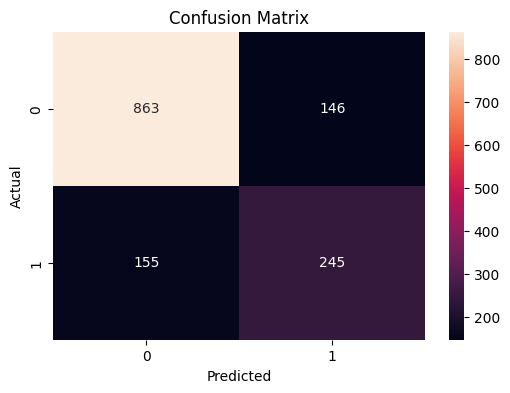

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [85]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                            Feature  Importance
2                     Total Charges    0.171526
0                     Tenure Months    0.153943
1                   Monthly Charges    0.128876
28  Payment Method_Electronic check    0.096917
10     Internet Service_Fiber optic    0.047726
26            Paperless Billing_Yes    0.043104
25                Contract_Two year    0.039886
6                    Dependents_Yes    0.031892
4                Senior Citizen_Yes    0.026086
3                       Gender_Male    0.023329


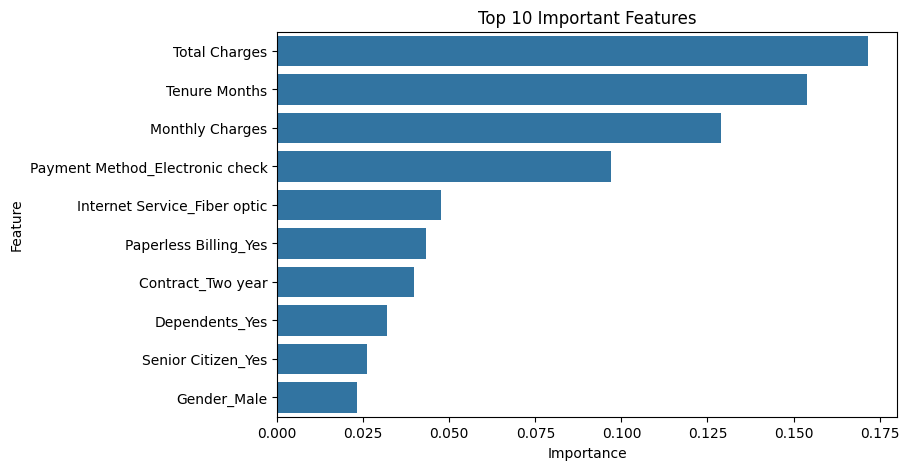

In [86]:
top10 = importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top10
)

plt.title("Top 10 Important Features")
plt.show()

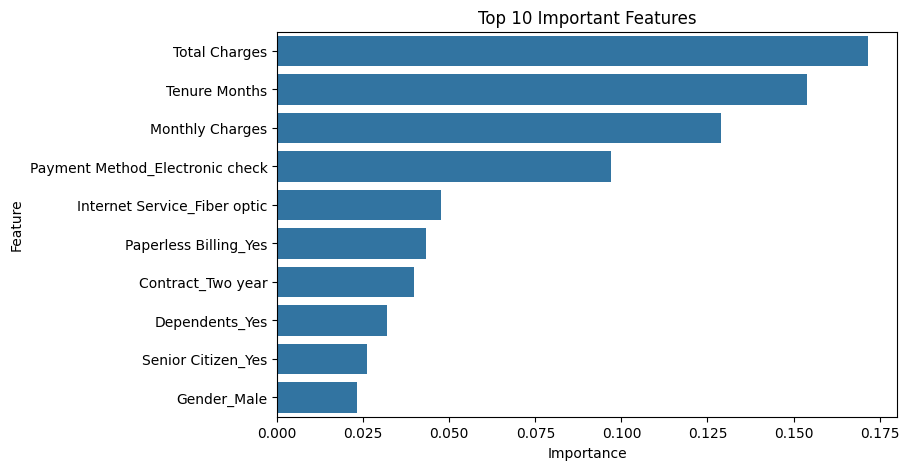

In [87]:
top10 = importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top10
)

plt.title("Top 10 Important Features")
plt.show()

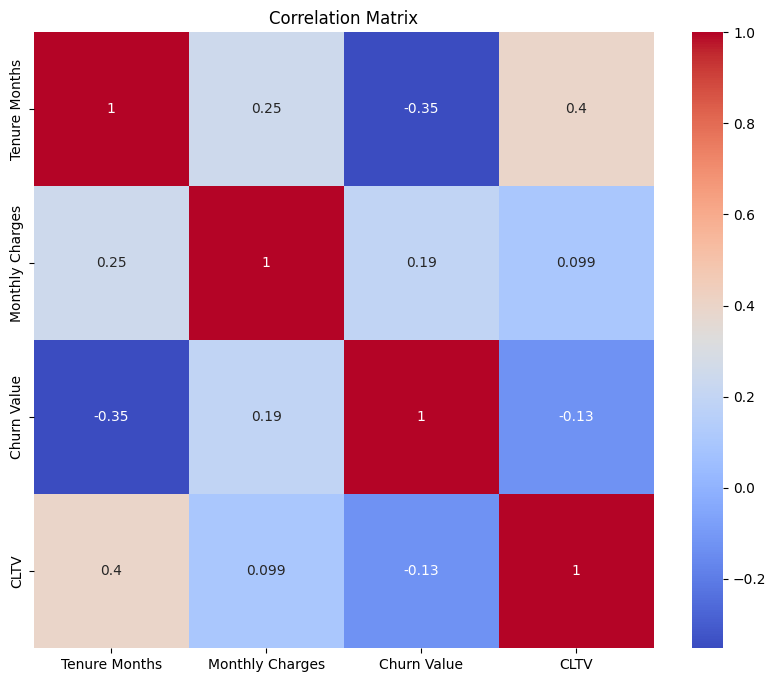

In [88]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [97]:
models = {

    'Logistic Regression':
    LogisticRegression(max_iter=3000),

    'Decision Tree':
    DecisionTreeClassifier(random_state=42),

    'Random Forest':
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'KNN':
    KNeighborsClassifier(),

    'SVM':
    SVC(),

    'Gradient Boosting':
    GradientBoostingClassifier(),

    'XGBoost':
    XGBClassifier()
}

results={}

for name, model in models.items():

    model.fit(
        X_train_smote,
        y_train_smote
    )

    pred=model.predict(X_test)

    acc=accuracy_score(
        y_test,
        pred
    )

    results[name]=acc

    print("\n",name)
    print("Accuracy:",acc)


 Logistic Regression
Accuracy: 0.7665010645848119

 Decision Tree
Accuracy: 0.964513839602555

 Random Forest
Accuracy: 0.9730305180979418

 KNN
Accuracy: 0.7970191625266146

 SVM
Accuracy: 0.801277501774308

 Gradient Boosting
Accuracy: 0.7970191625266146

 XGBoost
Accuracy: 0.914833215046132


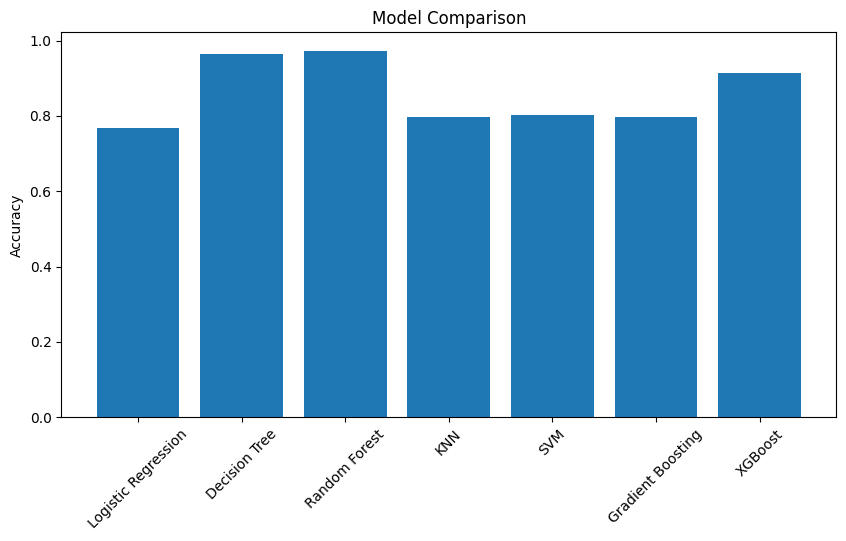

In [98]:
plt.figure(figsize=(10,5))

plt.bar(
    results.keys(),
    results.values()
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

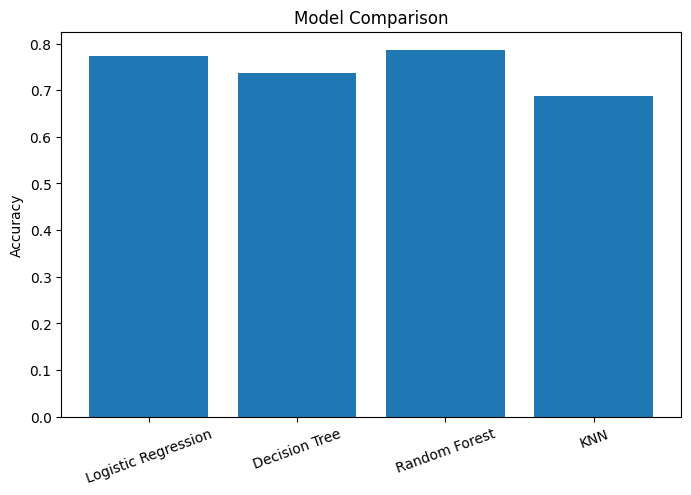

In [90]:
plt.figure(figsize=(8,5))

plt.bar(results.keys(),results.values())

plt.xticks(rotation=20)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

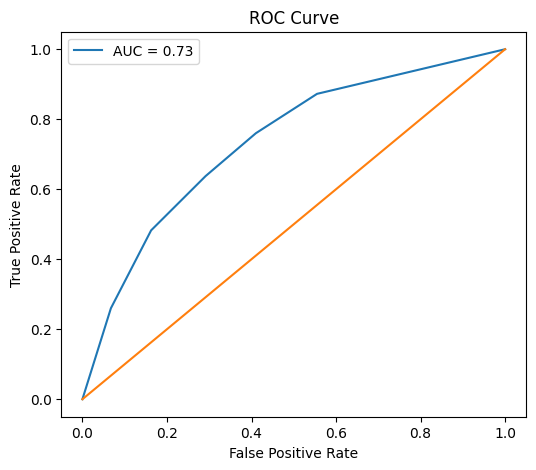

In [91]:
from sklearn.metrics import roc_curve, auc

prob = model.predict_proba(X_test)[:,1]

fpr,tpr,threshold = roc_curve(y_test,prob)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label='AUC = %0.2f'%roc_auc)

plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [92]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print(prediction)

if prediction[0]==1:
    print("Customer likely to churn")
else:
    print("Customer likely to stay")

[1]
Customer likely to churn
